In [3]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Restaurant sales analysis

In [ ]:
import pandas as pd

restaurant_df = pd.read_csv('restoran.csv.txt')

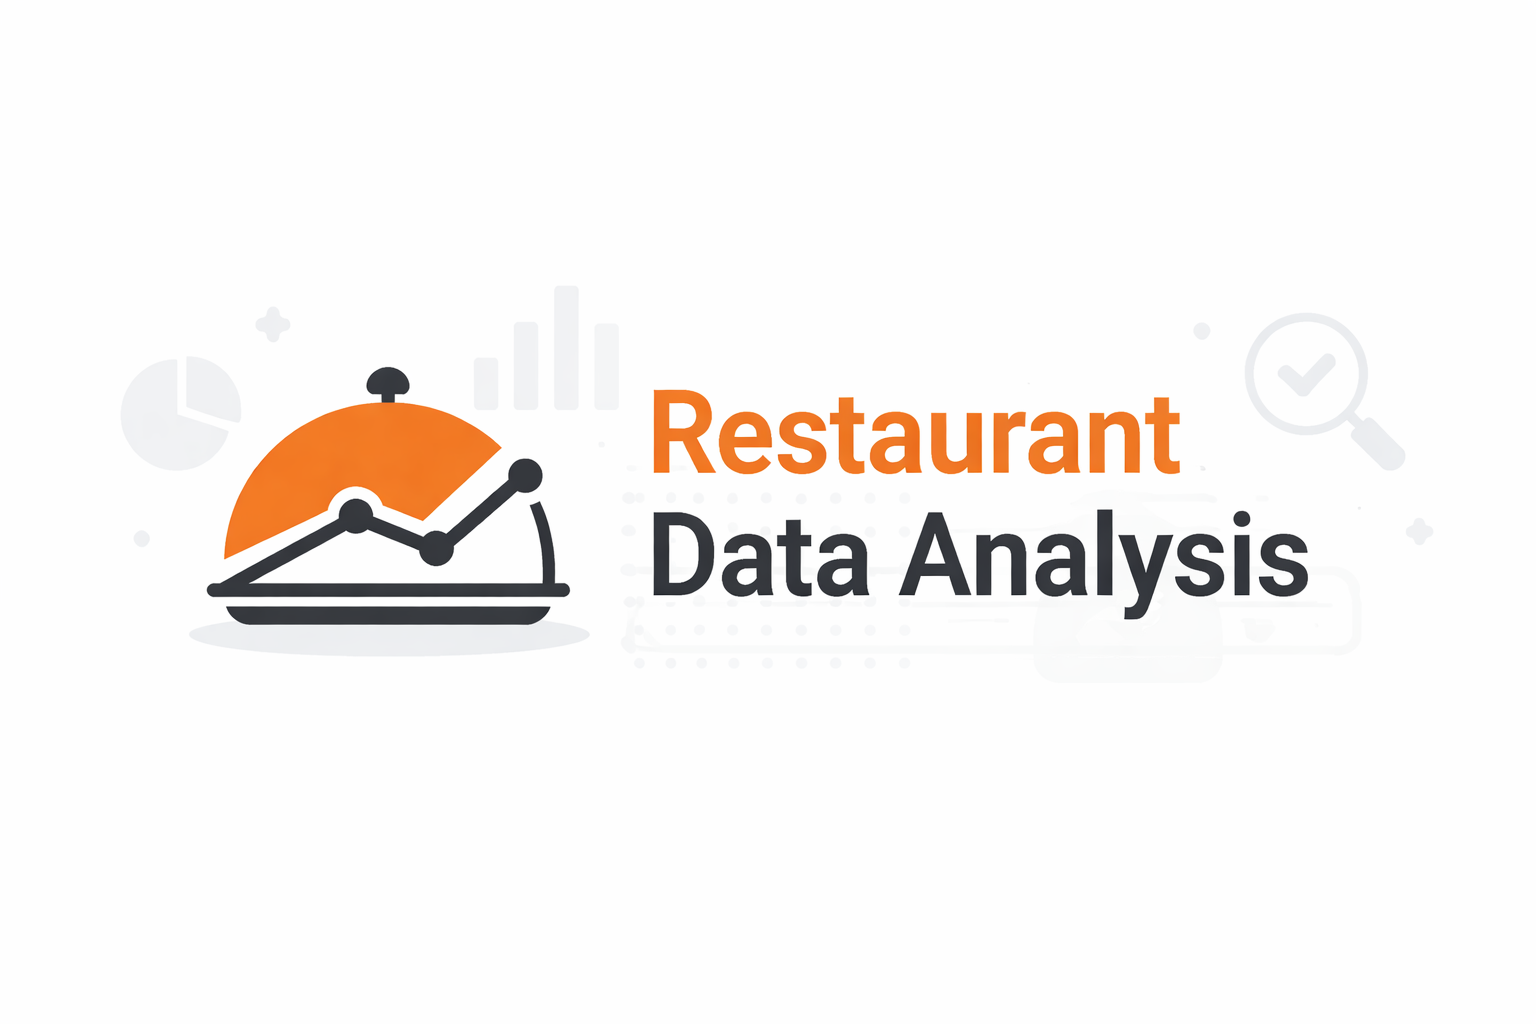

In [5]:
restaurant_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#####  This function displays the first 5 rows of the dataset.

In [6]:
restaurant_df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

##### The attribute returns the labels of the columns in the DataFrame.

In [7]:
restaurant_df.shape

(244, 7)

##### This attribute allows us to see the total number of columns in the dataset.244 rows and 7 columns

In [8]:
print(restaurant_df["time"].value_counts())

time
Dinner    176
Lunch      68
Name: count, dtype: int64


## Adding new columns

In [9]:
restaurant_df['food_item'] = restaurant_df['time'].apply(lambda x: 'Fish' if x == 'Dinner' else 'Pizza')


### 🍕 Adding Menu Items Based on Meal Time
To make our dataset more descriptive, we are adding a new column called **`food_item`**. 
We use a conditional logic where:
* If the time is **'Dinner'**, the assigned food is **'Fish'**.
* If the time is **'Lunch'**, the assigned food is **'Pizza'**.

This allows us to analyze which specific dishes are more popular or generate higher tips.

In [16]:
avarage_bill=restaurant_df["total_bill"].mean()
avarage_bill

np.float64(19.78594262295082)

In [11]:
restaurant_df['customer_class'] = restaurant_df['total_bill'].apply(lambda x: 'VIP' if x > 20 else 'Standard')

### 💎 2. Customer Segmentation (VIP vs. Standard)

To better understand our customer base, we have categorized each table into two segments based on the **Total Bill**:

* **VIP:** Tables with a total bill greater than **$20**. These are our high-spending customers.
* **Standard:** Tables with a total bill of **$20 or less**.

> **Objective:** This classification helps us analyze if "VIP" customers leave significantly higher tips compared to "Standard" customers.

In [ ]:

restaurant_df['daily_revenue'] = restaurant_df.groupby('day')['total_bill'].transform('sum')

### 💰 3. Daily Revenue Calculation
To understand the restaurant's performance on different days, we calculate the **Total Revenue** for each day and store it in a new column called `daily_revenue`.

* **Logic:** We use the `groupby` function on the 'day' column and apply `transform('sum')` to the 'total_bill'.
* **Benefit:** This allows us to compare individual table bills against the total earnings of that specific day.

> **Key Metric:** This column helps in identifying our most profitable days (e.g., Sunday vs. Saturday).

In [17]:
import numpy as np
restaurant_df['table_duration'] = np.random.randint(30, 121, size=len(restaurant_df))

### ⏳ 4. Dining Duration (Simulated)
I added a new column to show how long customers stayed, using **random numbers** between 30 and 120 minutes. 
**Logic:** `np.random.randint(30, 121)`

### 📊 Information about the dataset (11 Columns):

| Column Name | Description |
| :--- | :--- |
| **total_bill** | Total amount of the bill (USD) |
| **tip** | Tip amount given by the customer (USD) |
| **sex** | Gender of the person paying the bill |
| **smoker** | Whether there were smokers in the party (Yes/No) |
| **day** | Day of the week (Thur, Fri, Sat, Sun) |
| **time** | Time of the day (Lunch or Dinner) |
| **size** | Number of people in the party |
| **meal** | Categorized meal type based on time |
| **customer_class** | Customer segment based on bill amount (VIP if > $20) |
| **daily_revenue** | Total revenue generated by the restaurant on that specific day |
| **table_duration** | Estimated time spent at the table (30-120 minutes) |

In [ ]:
restaurant_df.sample(10)

,total_bill,tip,sex,smoker,day,time,size,food_item,customer_class,daily_revenue,table_duration
218,7.74,1.44,Male,Yes,Sat,Dinner,2,Fish,Standard,1778.40,118
95,40.17,4.73,Male,Yes,Fri,Dinner,4,Fish,VIP,325.88,65
66,16.45,2.47,Female,No,Sat,Dinner,2,Fish,Standard,1778.40,54
32,15.06,3.00,Female,No,Sat,Dinner,2,Fish,Standard,1778.40,81
115,17.31,3.50,Female,No,Sun,Dinner,2,Fish,Standard,1627.16,110
9,14.78,3.23,Male,No,Sun,Dinner,2,Fish,Standard,1627.16,61
174,16.82,4.00,Male,Yes,Sun,Dinner,2,Fish,Standard,1627.16,34
41,17.46,2.54,Male,No,Sun,Dinner,2,Fish,Standard,1627.16,99
203,16.40,2.50,Female,Yes,Thur,Lunch,2,Pizza,Standard,1096.33,42
186,20.90,3.50,Female,Yes,Sun,Dinner,3,Fish,VIP,1627.16,89


In [ ]:
restaurant_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total_bill      244 non-null    float64
 1   tip             244 non-null    float64
 2   sex             244 non-null    str    
 3   smoker          244 non-null    str    
 4   day             244 non-null    str    
 5   time            244 non-null    str    
 6   size            244 non-null    int64  
 7   food_item       244 non-null    str    
 8   customer_class  244 non-null    str    
 9   daily_revenue   244 non-null    float64
 10  table_duration  244 non-null    int32  
dtypes: float64(3), int32(1), int64(1), str(6)
memory usage: 20.1 KB


#### I used the `info()` method to get a quick overview of the dataset structure

In [ ]:
restaurant_df.isna()

,total_bill,tip,sex,smoker,day,time,size,food_item,customer_class,daily_revenue,table_duration
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
239,False,False,False,False,False,False,False,False,False,False,False
240,False,False,False,False,False,False,False,False,False,False,False
241,False,False,False,False,False,False,False,False,False,False,False
242,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
restaurant_df.isna().mean()

total_bill        0.0
tip               0.0
sex               0.0
smoker            0.0
day               0.0
time              0.0
size              0.0
food_item         0.0
customer_class    0.0
daily_revenue     0.0
table_duration    0.0
dtype: float64

###  Missing Data Percentage
I used `isna().mean()` to calculate the **percentage of missing values** in each column.There are no gaps in this dataset :)

In [ ]:
restaurant_df.groupby("sex").agg({"total_bill": ["mean","min","max"]})

total_bill             
             mean   min    max
sex                           
Female  18.056897  3.07  44.30
Male    20.744076  7.25  50.81

##### From this analysis, it can be concluded that **men paid higher total bills on average than women.**

In [ ]:
restaurant_df['tip_percentage'] = (restaurant_df['tip'] / restaurant_df['total_bill']) * 100

In [24]:
restaurant_df.sample(5)

,total_bill,tip,sex,smoker,day,time,size,food_item,customer_class,daily_revenue,table_duration,tip_percentage
63,18.29,3.76,Male,Yes,Sat,Dinner,4,Fish,Standard,1778.40,92,20.557682
211,25.89,5.16,Male,Yes,Sat,Dinner,4,Fish,VIP,1778.40,31,19.930475
227,20.45,3.00,Male,No,Sat,Dinner,4,Fish,VIP,1778.40,71,14.669927
11,35.26,5.00,Female,No,Sun,Dinner,4,Fish,VIP,1627.16,99,14.180374
210,30.06,2.00,Male,Yes,Sat,Dinner,3,Fish,VIP,1778.40,82,6.653360


In [26]:
restaurant_df.groupby(["sex","customer_class",]).agg({"tip_percentage": "mean",
                                                      "sex": "count"}).rename(columns={"sex": "count"})

tip_percentage  count
sex    customer_class                       
Female Standard             17.846713     60
       VIP                  13.987653     27
Male   Standard             17.019544     87
       VIP                  14.205904     70

##### Gender & Segment Analysis
I grouped the data by **Gender** and **Customer Class** to compare the average tip percentage and the total number of visits for each group.


In [30]:
print(restaurant_df["size"].value_counts())

size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64


In [29]:
customer_size_bill=restaurant_df.groupby(["size"]).agg({"total_bill":["mean","count"]}).reset_index()
customer_size_bill

size total_bill      
             mean count
0    1   7.242500     4
1    2  16.448013   156
2    3  23.277632    38
3    4  28.613514    37
4    5  30.068000     5
5    6  34.830000     4

In [31]:
print(restaurant_df["day"].value_counts())

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [ ]:
restaurant_df.groupby(["day", "sex"])["sex"].count()

day   sex   
Fri   Female     9
      Male      10
Sat   Female    28
      Male      59
Sun   Female    18
      Male      58
Thur  Female    32
      Male      30
Name: sex, dtype: int64

#####  Customer Counts by Day and Gender
I used the `groupby` method to count the number of male and female customers for each day. This gives us a clear breakdown of the restaurant's traffic based on gender.

In [36]:

restaurant_df.groupby(["day", "customer_class" , "daily_revenue"])["customer_class"].count()

day   customer_class  daily_revenue
Fri   Standard        325.88           13
      VIP             325.88            6
Sat   Standard        1778.40          49
      VIP             1778.40          38
Sun   Standard        1627.16          39
      VIP             1627.16          37
Thur  Standard        1096.33          46
      VIP             1096.33          16
Name: customer_class, dtype: int64

##### Based on the results, VIP customers mostly visit on Saturdays and Sundays, which suggests we should provide extra premium service on these days.

### 📊  Histogram of Total Weekly Sales

In [45]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)

   ------------- -------------------------- 1/3 [contourpy]
   ------------- -------------------------- 1/3 [contourpy]
   ------------- -------------------------- 1/3 [contourpy]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- --------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 1.1 MB/s eta 0:00:02
   ------------- -------------------------- 0.8/2.3 MB 1.3 MB/s eta 0:00:02
   ----------------- ---------------------- 1.0/2.3 MB 1.4 MB/s eta 0:00:01
   ----------------- ---------------------- 1.0/2.3 MB 1.4 MB/s eta 0:00:01
   -------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


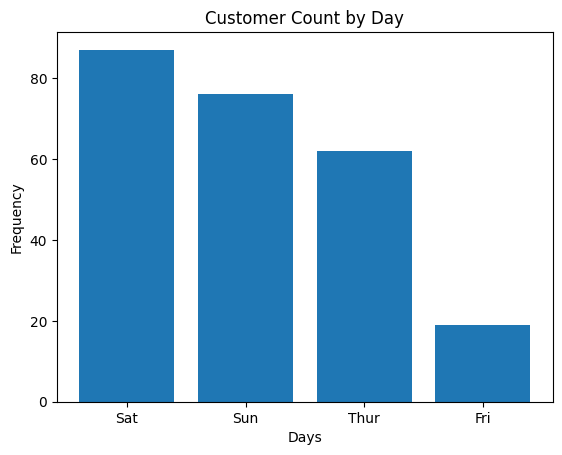

In [ ]:
import matplotlib.pyplot as plt

counts = restaurant_df['day'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.title('Customer Count by Day')
plt.show()

### Preparation of KPI

In [47]:

avg_bill = restaurant_df['total_bill'].mean()
avg_tip_pct = restaurant_df['tip_percentage'].mean()
top_day = restaurant_df.groupby('day')['total_bill'].sum().idxmax()

print(f"Orta hesab: {avg_bill:.2f}$")
print(f"Orta çaypulu: {avg_tip_pct:.2f}%")
print(f"Ən gəlirli gün: {top_day}")

Orta hesab: 19.79$
Orta çaypulu: 16.08%
Ən gəlirli gün: Sat
